# Isocurvature Forecast Workbook (CLASS → Fisher → Cobaya)
TT/TE/EE and optional BB (toggle with `INCLUDE_BB`).

Sections:
1. Isocurvature parameterizations + quick P(k) plots
2. CLASS examples (adiabatic + one isocurvature mode)
3. Fisher forecast (TT/TE/EE/(BB))
4. Cobaya forecast using a synthetic Gaussian bandpower likelihood


## 1. Cosmological model and parameters

We work with a fiducial cosmological model defined by a parameter vector

$$
\boldsymbol\theta = (\omega_b,\ \omega_c,\ h,\ A_s,\ n_s,\ \tau,\ \dots)
$$

extended to include **isocurvature degrees of freedom**, which arise in many
multi-field early-universe scenarios (e.g. axions, curvaton models).

### Why isocurvature?

- Adiabatic modes: all species fluctuate in phase
- Isocurvature modes: relative number densities fluctuate
- Observable consequence: different phase and amplitude patterns in CMB spectra

We will forecast how well a CMB experiment can constrain such departures from
pure adiabatic initial conditions.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Dict, List, Optional

HAVE_CLASSY = False
HAVE_COBAYA = False

try:
    from classy import Class
    HAVE_CLASSY = True
except Exception as e:
    print("WARNING: classy not available:", repr(e))

try:
    import cobaya  # noqa: F401
    HAVE_COBAYA = True
except Exception as e:
    print("WARNING: cobaya not available:", repr(e))


## 0. Controls

In [2]:
INCLUDE_BB = False   # set False to ignore BB everywhere for now
ELL_MIN = 2
ELL_MAX = 3000

SPECTRA = ["tt", "te", "ee"] + (["bb"] if INCLUDE_BB else [])
print("Using spectra:", SPECTRA)


Using spectra: ['tt', 'te', 'ee']


## 1. Isocurvature primordial power parameterizations

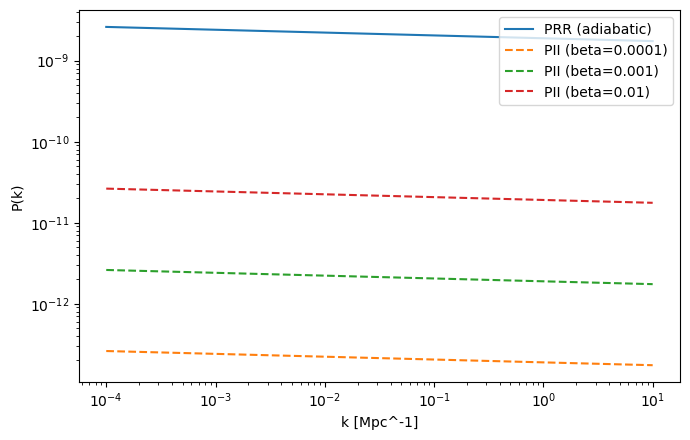

In [3]:
def adiabatic_Pk(k, As=2.1e-9, ns=0.965, k_pivot=0.05):
    k = np.asarray(k, float)
    return As * (k / k_pivot)**(ns - 1.0)

def isocurvature_Pk_from_beta(k, beta_iso, As=2.1e-9, ns=0.965, n_iso=None, k_pivot=0.05):
    # Uncorrelated iso fraction beta at pivot: PII/PRR = beta/(1-beta) at k_pivot
    if n_iso is None:
        n_iso = ns
    PRR = adiabatic_Pk(k, As=As, ns=ns, k_pivot=k_pivot)
    ratio = beta_iso / max(1e-12, (1.0 - beta_iso))
    PII_pivot = ratio * adiabatic_Pk(k_pivot, As=As, ns=ns, k_pivot=k_pivot)
    PII = PII_pivot * (k / k_pivot)**(n_iso - 1.0)
    return PRR, PII

def two_scale_Pk(k, p1, p2, k1, k2):
    # Log-linear interpolation between (k1,p1) and (k2,p2)
    k = np.asarray(k, float)
    lk = np.log(k); lk1 = np.log(k1); lk2 = np.log(k2)
    lp1 = np.log(p1); lp2 = np.log(p2)
    t = np.clip((lk - lk1) / (lk2 - lk1), 0.0, 1.0)
    return np.exp(lp1 + t*(lp2 - lp1))

k = np.logspace(-4, 1, 600)
PRR = adiabatic_Pk(k)

plt.figure(figsize=(7,4.5))
plt.loglog(k, PRR, label="PRR (adiabatic)")
for beta in [1e-4, 1e-3, 1e-2]:
    _, PII = isocurvature_Pk_from_beta(k, beta_iso=beta)
    plt.loglog(k, PII, ls="--", label=f"PII (beta={beta:g})")
plt.xlabel("k [Mpc^-1]")
plt.ylabel("P(k)")
plt.legend()
plt.tight_layout()
plt.show()


## 2. CLASS helpers (adiabatic + one isocurvature mode)
This assumes your CLASS build understands parameters like `f_cdi`, `n_cdi` (or `f_bi`, etc.).
If your build differs, edit `build_class_params` accordingly (this is the only place you should need to touch).

**From cosmological parameters to power spectra**

Given a set of cosmological parameters, we compute theoretical angular power spectra

$$
C_\ell^{XY}(\boldsymbol\theta), \quad X,Y \in \{T,E\}
$$

using the Boltzmann solver **CLASS**.

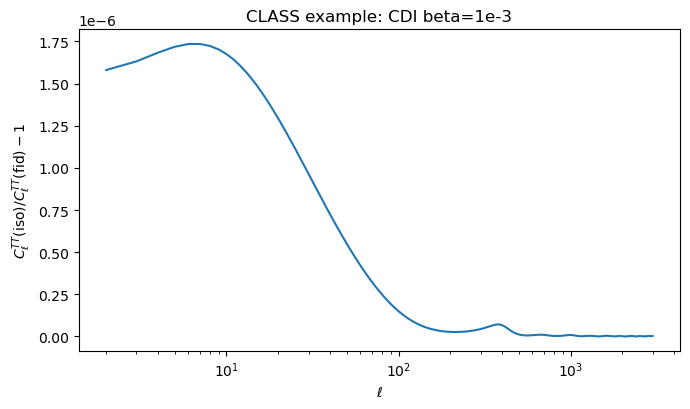

In [6]:
#@dataclass
#class CosmoParams:
#    omega_b: float = 0.02237
#    omega_cdm: float = 0.1200
#    H0: float = 67.36
#    As: float = 2.1e-9
#    ns: float = 0.965
#    tau_reio: float = 0.054
@dataclass
class CosmoParams:
    omega_b: float = 0.02237
    omega_cdm: float = 0.11933
    h: float = 0.6766
    As: float = 2.105e-9
    ns: float = 0.9665
    tau_reio: float = 0.0561
    T_cmb: float = 2.7255
    Pk_max_1_Mpc: float = 3.0

#@dataclass
#class IsoParams:
#    mode: str = "cdi"         # "cdi", "bi", "nid", "niv"
#    beta_iso: float = 0.0     # iso fraction at pivot
#    n_iso: Optional[float] = None
#    k_pivot: float = 0.05

@dataclass
class IsoParams:
    mode: str = "cdi"          # "cdi", "bi", "nid", "niv"
    beta_iso: float = 0.0      # we will map beta -> f_mode
    n_iso: float = 1.0
    alpha_iso: float = 0.0
    k_pivot: float = 0.05

    # two-scale option
    use_two_scales: bool = False
    k1: float = 0.002
    k2: float = 0.1
    PRR1: float = 2.105e-9
    PRR2: float = 2.105e-9
    PII1: float = 1e-13
    PII2: float = 1e-13
    PRI1: float = 1e-15
    PRI2_abs: float = 1e-15

def build_class_params(c: CosmoParams, iso: IsoParams, ell_max: int, lensing: bool=True) -> Dict:
    # Base params (match your conventions)
    params = {
        "omega_b": c.omega_b,
        "omega_cdm": c.omega_cdm,
        "h": c.h,
        "tau_reio": c.tau_reio,
        "A_s": c.As,
        "n_s": c.ns,
        "T_cmb": c.T_cmb,
        "P_k_max_1/Mpc": c.Pk_max_1_Mpc,
        "output": "tCl lCl pCl mPk",
        "l_max_scalars": int(ell_max),
        "lensing": "yes" if lensing else "no",
    }

    mode = iso.mode.lower()

    if iso.use_two_scales:
        # Always include both ICs in this mode (as in your dict)
        params["ic"] = f"ad {mode}"
        params["Pk_ini_type"] = "two_scales"
        params["k1"] = iso.k1
        params["k2"] = iso.k2

        # CLASS keys must match exactly
        params["P_{RR}^1"] = iso.PRR1
        params["P_{RR}^2"] = iso.PRR2
        params["P_{II}^1"] = iso.PII1
        params["P_{II}^2"] = iso.PII2
        params["P_{RI}^1"] = iso.PRI1
        params["|P_{RI}^2|"] = iso.PRI2_abs

        return params

    # analytic_Pk (beta -> f_mode)
    if iso.beta_iso <= 0:
        params["ic"] = "ad"
        return params

    params["ic"] = f"ad {mode}"
    params["Pk_ini_type"] = "analytic_Pk"
    params["k_pivot"] = iso.k_pivot
    params["alpha_s"] = 0.0

    # Map beta -> f_mode. Here we interpret beta as "fraction of primordial power in iso"
    # Your example uses f_cdi=0.2 directly, so we set f_mode = beta_iso
    params[f"f_{mode}"] = float(iso.beta_iso)      # <- matches your usage (0.2 means 20%)
    params[f"n_{mode}"] = float(iso.n_iso)
    params[f"alpha_{mode}"] = float(iso.alpha_iso)

    return params

def run_class_get_cls(class_params: Dict, ell_max: int) -> Dict[str, np.ndarray]:
    if not HAVE_CLASSY:
        raise RuntimeError("classy not available")
    cosmo = Class()
    cosmo.set(class_params)
    cosmo.compute()
    cls = cosmo.lensed_cl(int(ell_max))  # K^2
    Tcmb = cosmo.T_cmb()
    conv = (Tcmb * 1e6)**2               # -> uK^2
    out = {k: cls[k]*conv for k in ["tt","te","ee","bb"]}
    cosmo.struct_cleanup(); cosmo.empty()
    return out

# Example: compare TT for beta=0 vs beta=1e-3
if HAVE_CLASSY:
    c = CosmoParams()
    cls0 = run_class_get_cls(build_class_params(c, IsoParams("cdi", 0.0), ELL_MAX), ELL_MAX)
    cls1 = run_class_get_cls(build_class_params(c, IsoParams("cdi", 1e-3), ELL_MAX), ELL_MAX)
    ell = np.arange(len(cls0["tt"]))
    plt.figure(figsize=(7,4.2))
    plt.semilogx(ell[2:], cls1["tt"][2:]/cls0["tt"][2:] - 1.0)
    plt.xlabel(r"$\ell$")
    plt.ylabel(r"$C_\ell^{TT}(\mathrm{iso})/C_\ell^{TT}(\mathrm{fid}) - 1$")
    plt.title("CLASS example: CDI beta=1e-3")
    plt.tight_layout()
    plt.show()
else:
    print("Skipping CLASS example (classy not available).")


## 3. Noise model template
Replace with SO/ACT noise curves as needed. This is white noise + beam deconvolution.

**Experimental modeling**

Real experiments do not measure the theoretical spectra directly.
Instead, we observe

$$
\tilde C_\ell^{XY} = C_\ell^{XY} + N_\ell^{XY}
$$

where $(N_\ell)$ represents instrumental noise and beam effects.

**White noise approximation**

For a map depth \(\Delta_T\) or \(\Delta_P\) (in μK·arcmin):

$$
N_\ell^{EE} = N_\ell^{BB} =
\left(\Delta_P \frac{\pi}{180\times60}\right)^2 B_\ell^{-2}
$$

with a Gaussian beam

$$
B_\ell = \exp\!\left[-\frac{\ell(\ell+1)\sigma_b^2}{2}\right].
$$

**Sky fraction**

Partial sky coverage reduces the number of independent modes:

$$
(2\ell + 1) \;\longrightarrow\; (2\ell + 1)\,f_{\rm sky}.
$$

This enters directly into the covariance of power spectrum estimators.

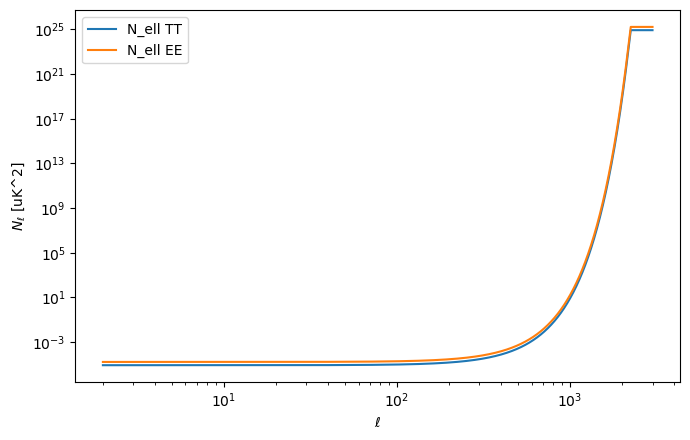

In [7]:
def beam_window(ell, fwhm_arcmin):
    ell = np.asarray(ell, float)
    sigma = (fwhm_arcmin*np.pi/180/60) / np.sqrt(8*np.log(2))
    return np.exp(-0.5*ell*(ell+1)*sigma**2)

def white_noise_Nl_uK2(ell, depth_uK_arcmin, fwhm_arcmin):
    w = (depth_uK_arcmin*np.pi/180/60)**2
    Bl = beam_window(ell, fwhm_arcmin)
    return w / np.maximum(Bl**2, 1e-30)

def get_noise_curves(ell, include_bb=INCLUDE_BB, depth_T=10.0, depth_P=14.0, fwhm_arcmin=30.0):
    N = {}
    N["tt"] = white_noise_Nl_uK2(ell, depth_T, fwhm_arcmin)
    N["ee"] = white_noise_Nl_uK2(ell, depth_P, fwhm_arcmin)
    N["te"] = np.zeros_like(ell, float)
    if include_bb:
        N["bb"] = white_noise_Nl_uK2(ell, depth_P, fwhm_arcmin)
    return N

ell = np.arange(ELL_MAX+1)
Nl = get_noise_curves(ell)

plt.figure(figsize=(7,4.5))
plt.loglog(ell[2:], Nl["tt"][2:], label="N_ell TT")
plt.loglog(ell[2:], Nl["ee"][2:], label="N_ell EE")
if INCLUDE_BB:
    plt.loglog(ell[2:], Nl["bb"][2:], label="N_ell BB")
plt.xlabel(r"$\ell$")
plt.ylabel(r"$N_\ell$ [uK^2]")
plt.legend()
plt.tight_layout()
plt.show()


## 4. Fisher forecast (TT/TE/EE and optional BB)

**Covariance of CMB power spectra**

The Gaussian covariance of estimated CMB power spectra at fixed multipole $\ell$ analytically is

$$
\mathrm{Cov}\!\left(\hat C_\ell^{XY}, \hat C_\ell^{WZ}\right)
=
\frac{1}{(2\ell+1)\,f_{\rm sky}}
\left(
\tilde C_\ell^{XW}\,\tilde C_\ell^{YZ}
+
\tilde C_\ell^{XZ}\,\tilde C_\ell^{YW}
\right),
$$

where $X,Y,W,Z \in \{T,E,B\}$, $\hat C_\ell^{XY}$ denotes the estimated power spectrum,
and $\tilde C_\ell^{XY} = C_\ell^{XY} + N_\ell^{XY}$ includes signal and noise.


**Fisher matrix**

The Fisher Information Matrix quantifies how much information a dataset contains
about model parameters.

\begin{equation}
F_{ij} = -\left\langle
\frac{\partial^2 \ln \mathcal{L}}{\partial \theta_i \, \partial \theta_j}
\right\rangle,
\qquad
\sigma(\theta_i) = \sqrt{(F^{-1})_{ii}}.
\end{equation}


The Fisher matrix is a local approximation—
it assumes the likelihood near the fiducial model is Gaussian in the parameters.
It tells us the curvature (or sharpness) of the likelihood peak, so larger curvature
means tighter constraints.


In the Fisher formalism, all information comes from the likelihood
$\mathcal{L}(\text{data} | \boldsymbol{\theta})$, which quantifies how probable the observed
data are given a set of parameters $\boldsymbol{\theta}$.
For the CMB, we work with the spherical harmonic coefficients
$a_{\ell m}^X$ ($X \in \{T,E,B\}$),
which for Gaussian skies are distributed as a multivariate Gaussian with zero mean and covariance
$\mathbf{C}_\ell(\boldsymbol{\theta})$:
$$
\mathcal{L}(\{a_{\ell m}\}|\boldsymbol{\theta})
= \prod_{\ell,m}
\frac{1}{(2\pi)^{3/2}|\mathbf{C}_\ell|^{1/2}}
\exp\!\left[-\frac{1}{2}
\mathbf{a}_{\ell m}^{\mathrm{T}}\mathbf{C}_\ell^{-1}\mathbf{a}_{\ell m}\right].
$$


Taking the logarithm and averaging over $m$ yields the
\emph{log-likelihood} (or ``Wishart likelihood'') for the estimated
power spectra:
\begin{equation}
-2\ln\mathcal{L} =
\sum_\ell (2\ell+1) f_{\mathrm{sky}}
\left[
\mathrm{Tr}\!\left(\hat{\mathbf{C}}_\ell \mathbf{C}_\ell^{-1}\right)
+ \ln|\mathbf{C}_\ell|
- \ln|\hat{\mathbf{C}}_\ell| - n_{\text{fields}}
\right],
\end{equation}
where $\hat{\mathbf{C}}_\ell$ is the sample covariance measured from the data,
$\mathbf{C}_\ell(\boldsymbol{\theta})$ is the model prediction,
$f_{\mathrm{sky}}$ is the observed sky fraction,
and $n_{\text{fields}}=3$ for $(T,E,B)$.

This likelihood assumes the CMB is a Gaussian field.
All cosmological information then resides in the covariance matrices $C_\ell$,
so forecasting reduces to studying how these covariances change with parameters.

The Fisher matrix is then defined as the expectation value of the curvature
(second derivative) of this log-likelihood at the fiducial model.
This connects the shape of the likelihood surface directly to the precision
with which parameters can be estimated.

For Gaussian CMB fields, the Fisher matrix is:
$$
F_{ij} = \sum_\ell \frac{2\ell+1}{2} f_{\mathrm{sky}}
\, \mathrm{Tr}\!\left[
\mathbf{C}_\ell^{-1}
\frac{\partial \mathbf{C}_\ell}{\partial \theta_i}
\mathbf{C}_\ell^{-1}
\frac{\partial \mathbf{C}_\ell}{\partial \theta_j}
\right],
$$
where $\mathbf{C}_\ell$ is the $3\times3$ covariance matrix
of $(TT,\,EE,\,BB)$, including both signal and noise.

Fisher 1-sigma:
     omega_b: 0.0005864
   omega_cdm: 0.00377
           h: 0.01975
          As: 3.485e-11
          ns: 0.01663
    tau_reio: 0.006102
    beta_iso: 385.9


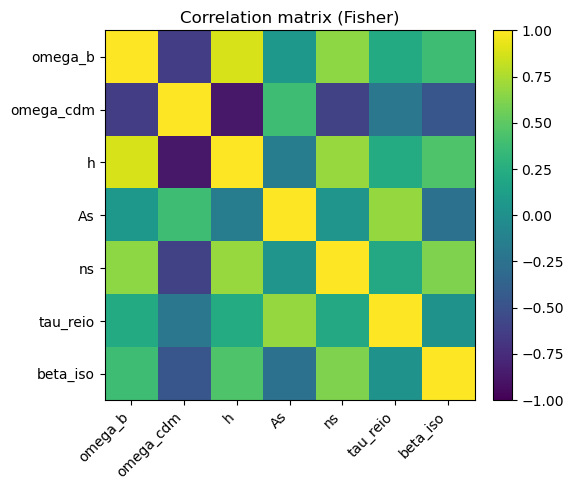

In [9]:
def finite_diff_deriv(get_cls_fn, theta0: Dict, name: str, step: float, ell_max: int):
    hi = dict(theta0); lo = dict(theta0)
    hi[name] = theta0[name] + step
    lo[name] = theta0[name] - step
    cls_hi = get_cls_fn(hi, ell_max)
    cls_lo = get_cls_fn(lo, ell_max)
    return {k: (cls_hi[k]-cls_lo[k])/(2*step) for k in cls_hi.keys()}

def fisher_TEBB(cls_fid, dcls, Nl, params, ell_min, ell_max, fsky, include_bb=INCLUDE_BB):
    F = np.zeros((len(params), len(params)))
    for ell in range(ell_min, ell_max+1):
        C = np.array([[cls_fid["tt"][ell] + Nl["tt"][ell], cls_fid["te"][ell]],
                      [cls_fid["te"][ell], cls_fid["ee"][ell] + Nl["ee"][ell]]], float)
        try:
            Cinv = np.linalg.inv(C)
        except np.linalg.LinAlgError:
            continue

        pref = (2*ell+1)*fsky/2.0
        dC = {p: np.array([[dcls[p]["tt"][ell], dcls[p]["te"][ell]],
                           [dcls[p]["te"][ell], dcls[p]["ee"][ell]]], float) for p in params}

        for i, pi in enumerate(params):
            for j, pj in enumerate(params[i:], start=i):
                tr = np.trace(Cinv @ dC[pi] @ Cinv @ dC[pj])
                F[i,j] += pref*tr
                if j != i: F[j,i] += pref*tr

        if include_bb:
            CBB = cls_fid["bb"][ell] + Nl["bb"][ell]
            invCBB2 = 1.0 / max(CBB*CBB, 1e-60)
            for i, pi in enumerate(params):
                dBi = dcls[pi]["bb"][ell]
                for j, pj in enumerate(params[i:], start=i):
                    dBj = dcls[pj]["bb"][ell]
                    F[i,j] += pref*(dBi*dBj)*invCBB2
                    if j != i: F[j,i] += pref*(dBi*dBj)*invCBB2
    return F

def add_priors_and_invert(F, params, priors=None):
    Fp = F.copy()
    if priors:
        for i,p in enumerate(params):
            if p in priors and priors[p] is not None:
                Fp[i,i] += 1.0/(priors[p]**2)
    return np.linalg.inv(Fp)

# Fiducial + parameter choices
cosmo_fid = CosmoParams()
iso_fid = IsoParams(mode="cdi", beta_iso=0.0)

#param_list = ["omega_b","omega_cdm","H0","As","ns","tau_reio","beta_iso"]
#steps = dict(omega_b=5e-5, omega_cdm=5e-4, H0=0.05, As=0.02e-9, ns=5e-4, tau_reio=5e-4, beta_iso=2e-4)
param_list = ["omega_b","omega_cdm","h","As","ns","tau_reio","beta_iso"]
steps = dict(omega_b=5e-5, omega_cdm=5e-4, h=5e-4, As=0.02e-9, ns=5e-4, tau_reio=5e-4, beta_iso=2e-4)
priors = {}     # e.g. {"tau_reio": 0.01}
fsky = 0.1

def cls_from_theta(theta: Dict, ell_max: int):
    c = CosmoParams(theta["omega_b"], theta["omega_cdm"], theta["h"], theta["As"], theta["ns"], theta["tau_reio"])
    iso = IsoParams(mode=iso_fid.mode, beta_iso=theta["beta_iso"], n_iso=iso_fid.n_iso, k_pivot=iso_fid.k_pivot)
    p = build_class_params(c, iso, ell_max)
    return run_class_get_cls(p, ell_max)

if HAVE_CLASSY:
    theta0 = dict(omega_b=cosmo_fid.omega_b, omega_cdm=cosmo_fid.omega_cdm, h=cosmo_fid.h,
                  As=cosmo_fid.As, ns=cosmo_fid.ns, tau_reio=cosmo_fid.tau_reio, beta_iso=iso_fid.beta_iso)

    cls_fid = cls_from_theta(theta0, ELL_MAX)
    dcls = {p: finite_diff_deriv(cls_from_theta, theta0, p, steps[p], ELL_MAX) for p in param_list}

    ell = np.arange(ELL_MAX+1)
    Nl = get_noise_curves(ell, include_bb=INCLUDE_BB)

    F = fisher_TEBB(cls_fid, dcls, Nl, param_list, ELL_MIN, ELL_MAX, fsky, include_bb=INCLUDE_BB)
    Cov = add_priors_and_invert(F, param_list, priors=priors)
    sig = np.sqrt(np.diag(Cov))

    print("Fisher 1-sigma:")
    for p,s in zip(param_list, sig):
        print(f"  {p:>10s}: {s:.4g}")

    corr = Cov / np.outer(sig, sig)
    plt.figure(figsize=(6,5))
    im = plt.imshow(corr, vmin=-1, vmax=1)
    plt.colorbar(im, fraction=0.046, pad=0.04)
    plt.xticks(range(len(param_list)), param_list, rotation=45, ha="right")
    plt.yticks(range(len(param_list)), param_list)
    plt.title("Correlation matrix (Fisher)")
    plt.tight_layout()
    plt.show()
else:
    print("Skipping Fisher (classy not available).")


,Fiducial Value,σ,S/N
Parameter,,,
omega_b,2.237000e-02,5.864151e-04,38.147040
omega_cdm,1.193300e-01,3.769784e-03,31.654330
h,6.766000e-01,1.975333e-02,34.252452
As,2.105000e-09,3.485358e-11,60.395509
ns,9.665000e-01,1.663446e-02,58.102277
tau_reio,5.610000e-02,6.101880e-03,9.193887
beta_iso,0.000000e+00,3.858866e+02,0.000000


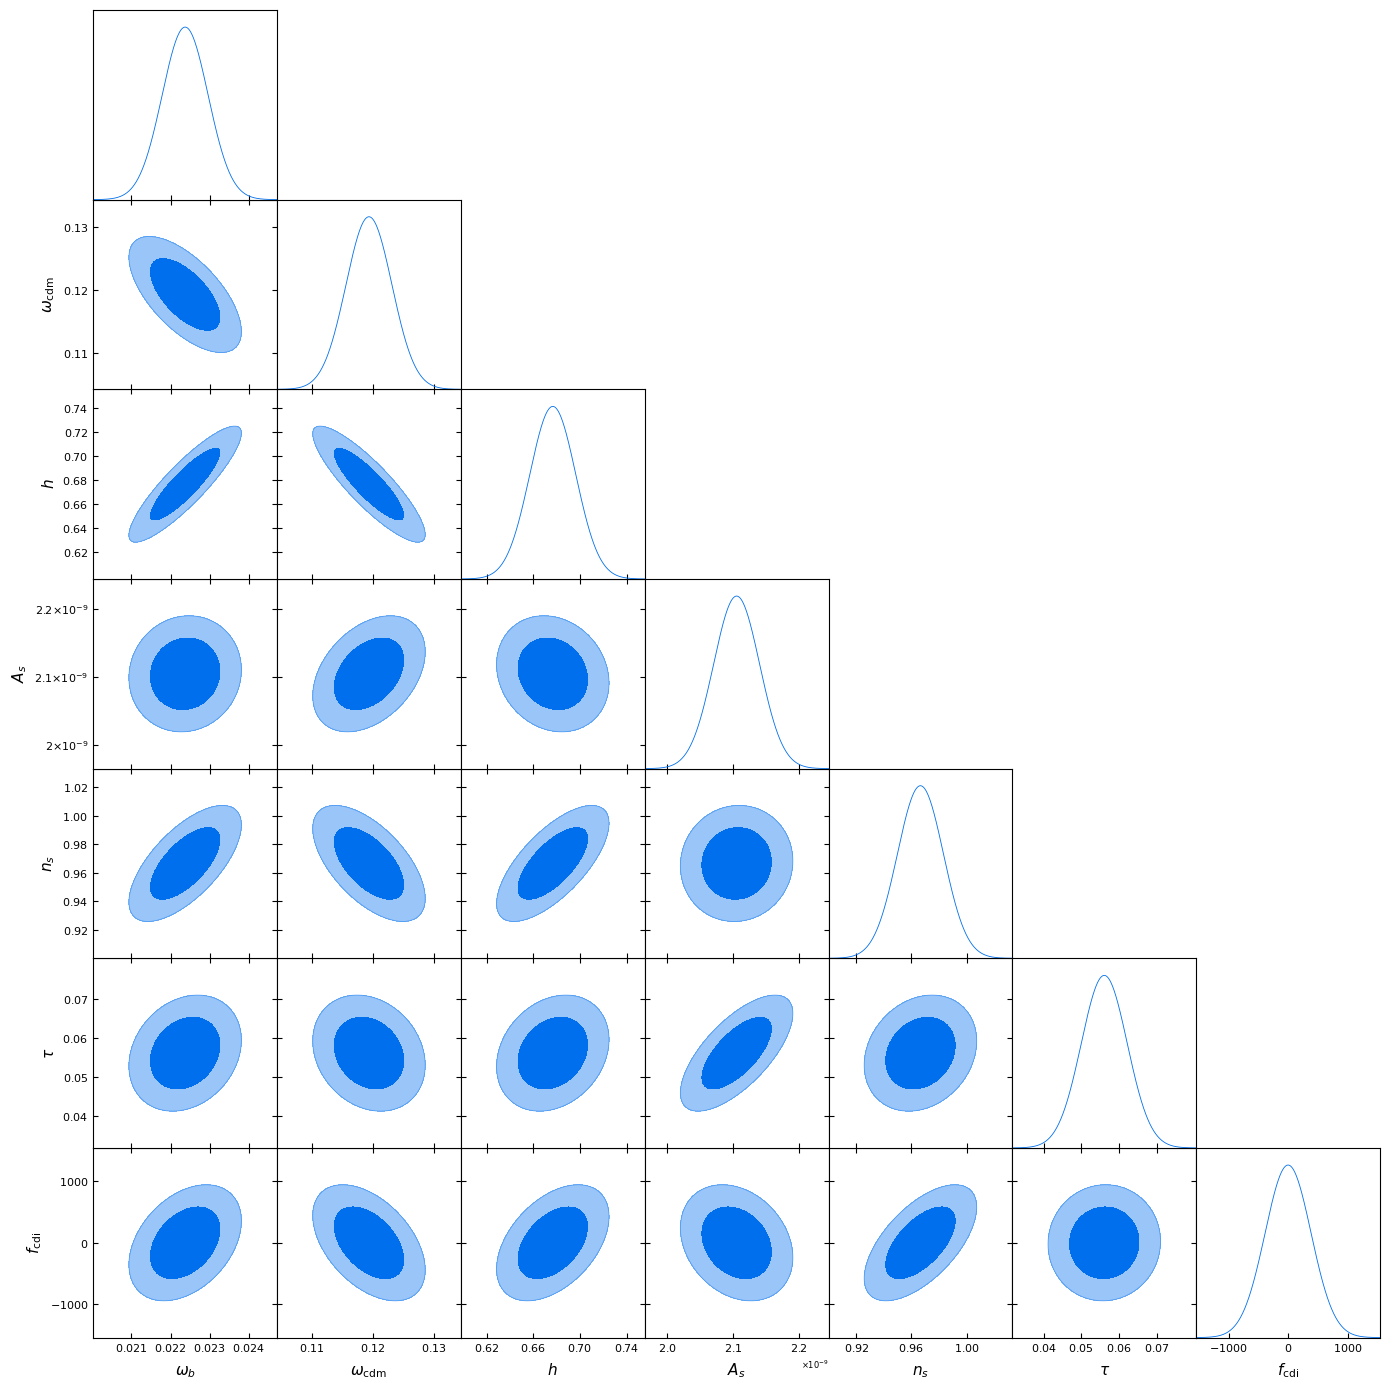

In [11]:
import numpy as np
import pandas as pd
from getdist.gaussian_mixtures import GaussianND
from getdist import plots

# ----------------------------
# Inputs you already have:
#   param_list : list[str]        (order used in Fisher)
#   theta0     : dict             (fiducials)
#   Cov        : ndarray (npar,npar)
# ----------------------------

# 1) Build centers vector in the SAME order as param_list
centers = np.array([theta0[p] for p in param_list], dtype=float)

# 2) 1-sigma
sigmas = np.sqrt(np.diag(Cov))

# 3) Table (avoid divide-by-zero warnings)
data = {
    "Parameter": param_list,
    "Fiducial Value": centers,
    "σ": sigmas,
    "S/N": np.divide(centers, sigmas, out=np.full_like(centers, np.nan), where=sigmas>0)
}
df = pd.DataFrame(data).set_index("Parameter")
display(df)

# 4) Labels (match your convention; update as needed)
latex_label_map = {
    "omega_b":   r"\omega_b",
    "omega_cdm": r"\omega_{\rm cdm}",
    "h":         r"h",
    "H0":        r"H_0",          # if you use H0 in some runs
    "As":        r"A_s",
    "ns":        r"n_s",
    "tau_reio":  r"\tau",
    "beta_iso":  r"f_{\rm cdi}",  # if you're treating beta_iso == f_cdi
    "f_cdi":     r"f_{\rm cdi}",
    "n_cdi":     r"n_{\rm cdi}",
}
latex_labels = [latex_label_map.get(p, p) for p in param_list]

# 5) Gaussian + triangle plot
gauss = GaussianND(
    centers,
    Cov,
    names=param_list,
    labels=latex_labels,
)

g = plots.get_subplot_plotter()
g.triangle_plot([gauss], param_list, filled=True)


## 5. Cobaya forecast (synthetic Gaussian bandpower likelihood)
Data vector = fiducial bandpowers. Covariance = simple diagonal Knox estimate (replace later).
Produces a YAML template you can save and run with `cobaya-run`.


While the Fisher matrix gives the expected precision for small perturbations,
Bayesian methods such as MCMC or nested sampling infer parameters from real data.

The Fisher forecast is a predictive tool,
not an inference method. It linearizes the likelihood near a fiducial model,
whereas MCMC explores the full non-linear likelihood surface.

**Fisher**: Fast, analytic, assumes Gaussian likelihood.
  - Useful for design and intuition.
  - Underestimates errors if posteriors are non-Gaussian or bounded (e.g., $r \ge 0$).
    
**Bayesian/MCMC**: Full likelihood sampling.
  - Slower but more accurate once data exist.
  - Recovers degeneracies and multi-modal posteriors.


i.e. Fisher forecast tells you how much curvature your likelihood would have if you had the data.
MCMC actually climbs the mountain once you have the data.

In [12]:
def bin_windows(ell, bin_edges):
    ell = np.asarray(ell)
    nb = len(bin_edges)-1
    W = np.zeros((nb, len(ell)))
    for b in range(nb):
        lo, hi = bin_edges[b], bin_edges[b+1]
        m = (ell>=lo) & (ell<hi)
        if np.any(m):
            W[b,m] = 1.0/np.sum(m)
    return W

def knox_diag_cov(cls_fid, Nl, ell, W, fsky, spectra):
    cov_blocks = []
    for s in spectra:
        if s == "te":
            var_ell = (((cls_fid["tt"]+Nl["tt"])*(cls_fid["ee"]+Nl["ee"]) + cls_fid["te"]**2)
                       / np.maximum((2*ell+1)*fsky, 1))
        else:
            var_ell = (2.0*(cls_fid[s]+Nl[s])**2) / np.maximum((2*ell+1)*fsky, 1)
        var_b = W @ var_ell
        cov_blocks.append(np.diag(var_b))
    cov = np.block([[cov_blocks[i] if i==j else np.zeros_like(cov_blocks[0])
                     for j in range(len(cov_blocks))]
                    for i in range(len(cov_blocks))])
    return cov

bin_edges = np.arange(ELL_MIN, ELL_MAX+1, 40)
ell = np.arange(ELL_MAX+1)
W = bin_windows(ell, bin_edges)
print("nbins:", W.shape[0])


nbins: 74


In [26]:
%%writefile iso_gaussian_like.py
import numpy as np
from cobaya.likelihood import Likelihood

class IsoGaussianBandpowers(Likelihood):
    # Options passed from YAML (must be declared!)
    data_npz: str = None
    l_max: int = None          # tell Cobaya how far in ell to compute

    def get_requirements(self):
        if self.l_max is None:
            raise ValueError("Set l_max for IsoGaussianBandpowers in the YAML.")
        # Request C_ell from the theory provider up to l_max
        return {"Cl": {"ell_max": int(self.l_max), "ell_factor": False}}

    def initialize(self):
        if self.data_npz is None:
            raise ValueError("Set data_npz in the YAML.")
        pack = np.load(self.data_npz, allow_pickle=True)
        self.d = pack["d"].astype(float)
        self.invcov = pack["invcov"].astype(float)
        self.W = pack["W"].astype(float)
        self.ell = pack["ell"].astype(int)
        self.spectra = list(pack["spectra"])

    def _bin(self, cl):
        return self.W @ cl[self.ell]

    def _model_vector(self, cls_dict):
        return np.concatenate([self._bin(cls_dict[s]) for s in self.spectra])

    def logp(self, **params_values):
        cls = self.provider.get_Cl(ell_factor=False)
        m = self._model_vector(cls)
        r = (self.d - m)
        return -0.5 * r @ self.invcov @ r


Overwriting iso_gaussian_like.py


In [21]:
# Build and save forecast data pack for Cobaya
if HAVE_CLASSY:
    ell = np.arange(ELL_MAX+1)
    Nl = get_noise_curves(ell, include_bb=INCLUDE_BB)

    theta0 = dict(omega_b=cosmo_fid.omega_b, omega_cdm=cosmo_fid.omega_cdm, h=cosmo_fid.h,
                  As=cosmo_fid.As, ns=cosmo_fid.ns, tau_reio=cosmo_fid.tau_reio, beta_iso=iso_fid.beta_iso)
    cls_fid = cls_from_theta(theta0, ELL_MAX)

    cov = knox_diag_cov(cls_fid, Nl, ell, W, fsky, SPECTRA)
    d = np.concatenate([W @ cls_fid[s] for s in SPECTRA])
    invcov = np.linalg.inv(cov + 1e-30*np.eye(cov.shape[0]))

    np.savez("iso_forecast_data.npz", d=d, invcov=invcov, W=W, ell=ell, spectra=np.array(SPECTRA, dtype=object))
    print("Wrote iso_forecast_data.npz")
else:
    print("Skipping data pack build (need classy).")


Wrote iso_forecast_data.npz


In [27]:
# Print a YAML template for Cobaya
yaml_text = '''
theory:
  classy:
    extra_args:
      output: "tCl,pCl,lCl"
      lensing: "yes"
      l_max_scalars: 2500
      Pk_ini_type: "analytic_Pk"
      k_pivot: 0.05
      ic: "ad cdi"
      n_cdi: 1.0
      alpha_cdi: 0.0
      alpha_s: 0.0

likelihood:
  iso_gaussian_like.IsoGaussianBandpowers:
    data_npz: "iso_forecast_data.npz"
    l_max: 2500

params:
  omega_b:   {prior: {min: 0.018, max: 0.026}}
  omega_cdm: {prior: {min: 0.08,  max: 0.16}}
  h:         {prior: {min: 0.55,  max: 0.80}}
  A_s:       {prior: {min: 1e-9,  max: 3e-9}}
  n_s:       {prior: {min: 0.9,   max: 1.05}}
  tau_reio:  {prior: {min: 0.01,  max: 0.15}}

  # Sample the actual CLASS iso amplitude directly
  f_cdi:     {prior: {min: 0.0,   max: 0.2}}

sampler:
  mcmc:
    burn_in: 200
    covmat: auto
    Rminus1_stop: 0.01
'''
print(yaml_text)
print("\nRun: cobaya-run iso_forecast.yaml -o chains/iso_forecast")


theory:
  classy:
    extra_args:
      output: "tCl,pCl,lCl"
      lensing: "yes"
      l_max_scalars: 2500
      Pk_ini_type: "analytic_Pk"
      k_pivot: 0.05
      ic: "ad cdi"
      n_cdi: 1.0
      alpha_cdi: 0.0
      alpha_s: 0.0

likelihood:
  iso_gaussian_like.IsoGaussianBandpowers:
    data_npz: "iso_forecast_data.npz"
    l_max: 2500

params:
  omega_b:   {prior: {min: 0.018, max: 0.026}}
  omega_cdm: {prior: {min: 0.08,  max: 0.16}}
  h:         {prior: {min: 0.55,  max: 0.80}}
  A_s:       {prior: {min: 1e-9,  max: 3e-9}}
  n_s:       {prior: {min: 0.9,   max: 1.05}}
  tau_reio:  {prior: {min: 0.01,  max: 0.15}}

  # Sample the actual CLASS iso amplitude directly
  f_cdi:     {prior: {min: 0.0,   max: 0.2}}

sampler:
  mcmc:
    burn_in: 200
    covmat: auto
    Rminus1_stop: 0.01


Run: cobaya-run iso_forecast.yaml -o chains/iso_forecast


In [28]:
import yaml

mode = iso_fid.mode  # e.g. "cdi"

config = {
    "theory": {
        "classy": {
            "extra_args": {
                "output": "tCl lCl pCl mPk",
                "lensing": "yes",
                "l_max_scalars": int(ELL_MAX),
                "Pk_ini_type": "analytic_Pk",
                "k_pivot": iso_fid.k_pivot,
                "ic": f"ad {mode}",
                # match your CLASS iso settings
                f"n_{mode}": 1.0,
                f"alpha_{mode}": 0.0,
                "alpha_s": 0.0,
                # optional
                # "P_k_max_1/Mpc": 3.0,
                # "T_cmb": 2.7255,
            }
        }
    },
    "likelihood": {
        "iso_gaussian_like.IsoGaussianBandpowers": {
            "data_npz": "iso_forecast_data.npz",
            "l_max": int(ELL_MAX),   # <-- ADD THIS (must match your data/vector ell max)
        }
    },
    "params": {
        "omega_b":   {"prior": {"min": 0.018, "max": 0.026}},
        "omega_cdm": {"prior": {"min": 0.08,  "max": 0.16}},
        "h":         {"prior": {"min": 0.55,  "max": 0.80}},
        "A_s":       {"prior": {"min": 1e-9,  "max": 3e-9}},
        "n_s":       {"prior": {"min": 0.9,   "max": 1.05}},
        "tau_reio":  {"prior": {"min": 0.01,  "max": 0.15}},
        # sample the CLASS isocurvature amplitude directly (no derived mapping)
        f"f_{mode}": {"prior": {"min": 0.0,   "max": 0.2}},
    },
    "sampler": {
        "mcmc": {
            "burn_in": 200,
            "covmat": "auto",
            "Rminus1_stop": 0.01,
        }
    }
}

yaml_file = "iso_forecast.yaml"
with open(yaml_file, "w") as f:
    yaml.dump(config, f, sort_keys=False)

print(f"Wrote {yaml_file}")
print("Run: cobaya-run iso_forecast.yaml -o chains/iso_forecast")


Wrote iso_forecast.yaml
Run: cobaya-run iso_forecast.yaml -o chains/iso_forecast
